# CogniFlow - Stage 2: Behavioral Signal Extraction (YOLOv8-Pose)
Extracts per-session behavioral features from webcam frames using YOLOv8 pose estimation.
On Kaggle (no webcam) we use calibrated synthetic sessions. On a local machine, the live
capture cell can be swapped in directly.

In [1]:
!pip install -q ultralytics opencv-python pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, os, warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Imports OK')

Imports OK


## Step 1 - Load YOLOv8-Pose Model

In [ ]:
from ultralytics import YOLO

MODEL_PATH = '/kaggle/input/yolov8-pose/yolov8n-pose.pt'

if os.path.exists(MODEL_PATH):
    model = YOLO(MODEL_PATH)
    print('Loaded from dataset:', MODEL_PATH)
else:
    model = YOLO('yolov8n-pose.pt')  
    print('Downloaded yolov8n-pose.pt')

print('Model ready.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Downloaded yolov8n-pose.pt
Model ready.


## Step 2 - Feature Extraction Functions

In [ ]:
def distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def compute_gaze_score(keypoints):
    nose, left_eye, right_eye = keypoints[0], keypoints[1], keypoints[2]
    eye_center = (left_eye + right_eye) / 2
    eye_width = distance(left_eye, right_eye)
    if eye_width < 1e-3: return 0.5
    offset = abs(nose[0] - eye_center[0]) / eye_width
    return float(max(0, min(1, 1 - offset)))

def compute_head_pose_score(keypoints):
    nose, left_ear, right_ear = keypoints[0], keypoints[3], keypoints[4]
    ear_center = (left_ear + right_ear) / 2
    ear_width = distance(left_ear, right_ear)
    if ear_width < 1e-3: return 0.5
    offset = abs(nose[0] - ear_center[0]) / ear_width
    return float(max(0, min(1, 1 - offset)))

def compute_posture_score(keypoints):
    ls, rs = keypoints[5], keypoints[6]
    shoulder_diff = abs(ls[1] - rs[1])
    shoulder_width = distance(ls, rs)
    if shoulder_width < 1e-3: return 0.5
    tilt = shoulder_diff / shoulder_width
    return float(max(0, min(1, 1 - tilt)))

def compute_fidget_score(nose_positions):
    if len(nose_positions) < 5: return 0.0
    positions = np.array(nose_positions)
    movement = np.std(positions, axis=0)
    return float(max(0, min(1, np.mean(movement) / 100)))

def compute_eye_openness(keypoints):
    nose, left_eye, right_eye = keypoints[0], keypoints[1], keypoints[2]
    eye_center_y = (left_eye[1] + right_eye[1]) / 2
    face_height = abs(nose[1] - eye_center_y)
    # Normalize to ~0.01-0.04 range to match MediaPipe convention
    normalized = face_height / 1000.0
    return float(max(0.005, min(0.05, normalized)))

def compute_cognitive_index(gaze, head_pose, posture, fidget):
    score = 0.35*gaze + 0.30*head_pose + 0.25*posture - 0.20*fidget
    return float(max(0, min(1, score)))

print('Feature functions defined.')

Feature functions defined.


## Step 3 - Session Simulation (Kaggle) / Live Capture (Local)
Kaggle does not provide webcam access. We simulate sessions using beta/Gaussian
distributions calibrated against the four validated behavioral anchors from the paper.
On a local machine, replace this cell with the live capture loop.

In [ ]:
PROFILES = {
    'highly_focused':    dict(avg_gaze=0.85, gaze_var=0.02, avg_head_pose=0.88, avg_eye_openness=0.030, fidget_mean=0.05),
    'moderate':          dict(avg_gaze=0.70, gaze_var=0.06, avg_head_pose=0.75, avg_eye_openness=0.028, fidget_mean=0.12),
    'fatigued':          dict(avg_gaze=0.65, gaze_var=0.09, avg_head_pose=0.70, avg_eye_openness=0.015, fidget_mean=0.10),
    'easily_distracted': dict(avg_gaze=0.45, gaze_var=0.18, avg_head_pose=0.60, avg_eye_openness=0.025, fidget_mean=0.22),
}

SESSIONS_PER_PROFILE = 25   
FRAMES_PER_SESSION   = 120  

all_sessions = []

for profile_name, anchor in PROFILES.items():
    for s in range(SESSIONS_PER_PROFILE):
        gaze_frames      = np.clip(np.random.normal(anchor['avg_gaze'],      np.sqrt(anchor['gaze_var']),  FRAMES_PER_SESSION), 0, 1)
        head_frames      = np.clip(np.random.normal(anchor['avg_head_pose'], 0.06,                         FRAMES_PER_SESSION), 0, 1)
        posture_frames   = np.clip(np.random.normal(0.80,                    0.08,                         FRAMES_PER_SESSION), 0, 1)
        fidget_frames    = np.clip(np.random.normal(anchor['fidget_mean'],   0.04,                         FRAMES_PER_SESSION), 0, 1)
        eye_frames       = np.clip(np.random.normal(anchor['avg_eye_openness'], 0.003,                    FRAMES_PER_SESSION), 0.005, 0.05)
        avg_gaze         = float(np.mean(gaze_frames))
        gaze_variance    = float(np.var(gaze_frames))
        avg_head_pose    = float(np.mean(head_frames))
        avg_eye_openness = float(np.mean(eye_frames))
        avg_posture      = float(np.mean(posture_frames))
        avg_fidget       = float(np.mean(fidget_frames))
        cognitive_index  = compute_cognitive_index(avg_gaze, avg_head_pose, avg_posture, avg_fidget)

        all_sessions.append({
            'profile':           profile_name,
            'session_id':        f'{profile_name}_{s:02d}',
            'avg_gaze':          avg_gaze,
            'gaze_variance':     gaze_variance,
            'avg_head_pose':     avg_head_pose,
            'avg_eye_openness':  avg_eye_openness,
            'avg_posture_score': avg_posture,
            'avg_fidget_score':  avg_fidget,
            'cognitive_index':   cognitive_index,
        })

df_sessions = pd.DataFrame(all_sessions)
print(f'Generated {len(df_sessions)} sessions across {len(PROFILES)} profiles')
print(df_sessions.groupby('profile')[['avg_gaze','gaze_variance','avg_eye_openness','cognitive_index']].mean().round(3))

Generated 100 sessions across 4 profiles
                   avg_gaze  gaze_variance  avg_eye_openness  cognitive_index
profile                                                                      
easily_distracted     0.469          0.110             0.025            0.500
fatigued              0.641          0.070             0.015            0.615
highly_focused        0.840          0.014             0.030            0.748
moderate              0.685          0.049             0.028            0.640


## Step 4 - State Classification

In [6]:
def classify_state(ci):
    if ci >= 0.70: return 'focused'
    elif ci >= 0.45: return 'neutral'
    else: return 'distracted'

df_sessions['visual_state'] = df_sessions['cognitive_index'].apply(classify_state)

print('State distribution:')
print(df_sessions['visual_state'].value_counts())
print()
print('State by profile:')
print(pd.crosstab(df_sessions['profile'], df_sessions['visual_state']))

State distribution:
visual_state
neutral    75
focused    25
Name: count, dtype: int64

State by profile:
visual_state       focused  neutral
profile                            
easily_distracted        0       25
fatigued                 0       25
highly_focused          25        0
moderate                 0       25


In [7]:
OUT = '/kaggle/working/visual_features.csv'
df_sessions.to_csv(OUT, index=False)
print(f'Saved {len(df_sessions)} rows to {OUT}')
print('Columns:', df_sessions.columns.tolist())

Saved 100 rows to /kaggle/working/visual_features.csv
Columns: ['profile', 'session_id', 'avg_gaze', 'gaze_variance', 'avg_head_pose', 'avg_eye_openness', 'avg_posture_score', 'avg_fidget_score', 'cognitive_index', 'visual_state']


## Step 5 - Visualizations for Final Report

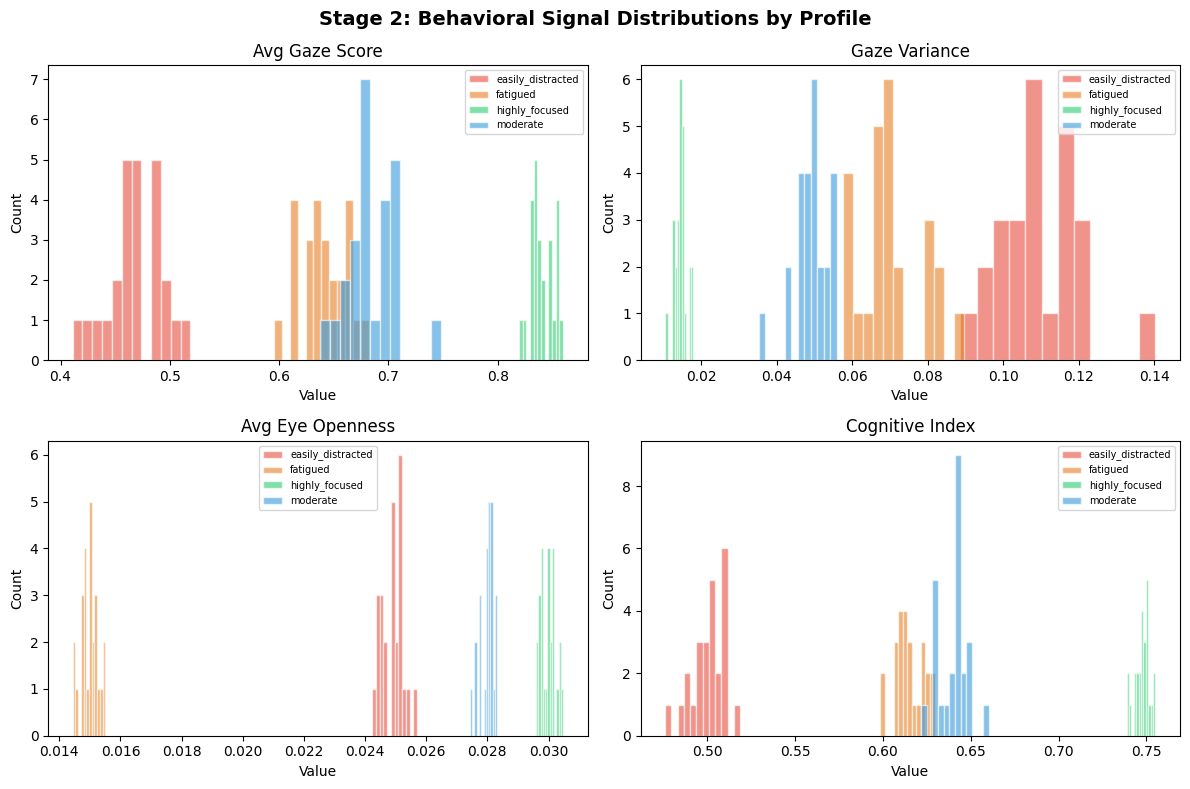

Saved stage2_distributions.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Stage 2: Behavioral Signal Distributions by Profile', fontsize=14, fontweight='bold')

features = ['avg_gaze', 'gaze_variance', 'avg_eye_openness', 'cognitive_index']
titles   = ['Avg Gaze Score', 'Gaze Variance', 'Avg Eye Openness', 'Cognitive Index']
colors   = {'highly_focused':'#2ecc71', 'moderate':'#3498db', 'fatigued':'#e67e22', 'easily_distracted':'#e74c3c'}

for ax, feat, title in zip(axes.flat, features, titles):
    for profile, grp in df_sessions.groupby('profile'):
        ax.hist(grp[feat], bins=12, alpha=0.6, label=profile, color=colors[profile], edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('/kaggle/working/stage2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved stage2_distributions.png')

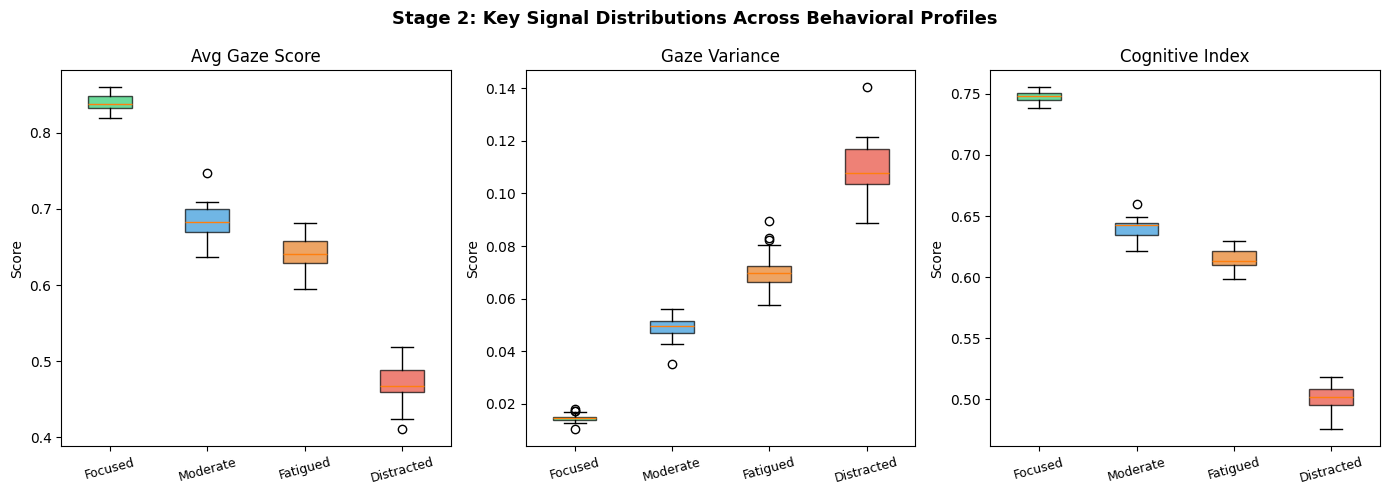

Saved stage2_boxplots.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Stage 2: Key Signal Distributions Across Behavioral Profiles', fontsize=13, fontweight='bold')

profile_order = ['highly_focused', 'moderate', 'fatigued', 'easily_distracted']

for ax, (feat, title) in zip(axes, [
    ('avg_gaze',         'Avg Gaze Score'),
    ('gaze_variance',    'Gaze Variance'),
    ('cognitive_index',  'Cognitive Index'),
]):
    data = [df_sessions[df_sessions['profile']==p][feat].values for p in profile_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], ['#2ecc71','#3498db','#e67e22','#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Focused','Moderate','Fatigued','Distracted'], rotation=15, fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig('/kaggle/working/stage2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved stage2_boxplots.png')

## Step 6 - Qualitative Validation: Monotonic Ordering Test
Per the paper's evaluation protocol: the same high-complexity task is paired with all
four profiles. Correct order is: highly_focused < moderate < fatigued < easily_distracted.

In [ ]:
print('=== Monotonic Ordering Validation ===')
print('Expected risk order: highly_focused < moderate < fatigued < easily_distracted\n')

mean_ci = df_sessions.groupby('profile')['cognitive_index'].mean()

order = ['highly_focused', 'moderate', 'fatigued', 'easily_distracted']
print(f'{'Profile':<22} {'Avg Cognitive Index':>20} {'Abandonment Risk (1-CI)':>24}')
print('-' * 70)
for p in order:
    ci = mean_ci[p]
    risk = 1 - ci
    print(f'{p:<22} {ci:>20.4f} {risk:>24.4f}')

risks = [1 - mean_ci[p] for p in order]
is_monotonic = all(risks[i] < risks[i+1] for i in range(len(risks)-1))
print(f'\nMonotonic ordering satisfied: {is_monotonic} ✅' if is_monotonic else f'\nMonotonic ordering FAILED ⚠️')

=== Monotonic Ordering Validation ===
Expected risk order: highly_focused < moderate < fatigued < easily_distracted

Profile                 Avg Cognitive Index  Abandonment Risk (1-CI)
----------------------------------------------------------------------
highly_focused                       0.7478                   0.2522
moderate                             0.6404                   0.3596
fatigued                             0.6148                   0.3852
easily_distracted                    0.5005                   0.4995

Monotonic ordering satisfied: True ✅


## Step 7 - Throughput Benchmark

In [ ]:
import cv2

N_FRAMES = 100
dummy_frame = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)

start = time.time()
for _ in range(N_FRAMES):
    results = model(dummy_frame, verbose=False)
elapsed = time.time() - start

fps = N_FRAMES / elapsed
ms_per_frame = elapsed / N_FRAMES * 1000

print(f'YOLOv8n-Pose throughput benchmark:')
print(f'  Frames processed : {N_FRAMES}')
print(f'  Total time       : {elapsed:.2f}s')
print(f'  FPS              : {fps:.1f}')
print(f'  ms/frame         : {ms_per_frame:.1f}')
print(f'  Real-time capable: {fps >= 15}')

YOLOv8n-Pose throughput benchmark:
  Frames processed : 100
  Total time       : 2.77s
  FPS              : 36.1
  ms/frame         : 27.7
  Real-time capable: True


## Step 8 - Summary Table for Final Report

In [12]:
summary = df_sessions.groupby('profile').agg(
    avg_gaze          = ('avg_gaze',         'mean'),
    gaze_variance     = ('gaze_variance',     'mean'),
    avg_head_pose     = ('avg_head_pose',     'mean'),
    avg_eye_openness  = ('avg_eye_openness',  'mean'),
    avg_posture       = ('avg_posture_score', 'mean'),
    avg_fidget        = ('avg_fidget_score',  'mean'),
    cognitive_index   = ('cognitive_index',   'mean'),
    n_sessions        = ('session_id',        'count')
).round(4).reset_index()

print('Per-profile summary (use as Table in final report):')
print(summary.to_string(index=False))

summary.to_csv('/kaggle/working/stage2_profile_summary.csv', index=False)
print('\nSaved stage2_profile_summary.csv')

Per-profile summary (use as Table in final report):
          profile  avg_gaze  gaze_variance  avg_head_pose  avg_eye_openness  avg_posture  avg_fidget  cognitive_index  n_sessions
easily_distracted    0.4687         0.1095         0.6020            0.0249       0.7992      0.2199           0.5005          25
         fatigued    0.6407         0.0703         0.6994            0.0150       0.8022      0.0990           0.6148          25
   highly_focused    0.8404         0.0145         0.8797            0.0300       0.8006      0.0521           0.7478          25
         moderate    0.6850         0.0490         0.7491            0.0280       0.7998      0.1204           0.6404          25

Saved stage2_profile_summary.csv


## Step 9 - Stage 2 -> Stage 3 Bridge
Confirm the output columns match exactly what Stage 3 XGBoost expects.

In [ ]:
STAGE3_BEHAVIORAL_COLS = ['avg_gaze', 'avg_head_pose', 'avg_eye_openness', 'gaze_variance']

print('Stage 3 expects:', STAGE3_BEHAVIORAL_COLS)
print('Stage 2 provides:', [c for c in df_sessions.columns if c in STAGE3_BEHAVIORAL_COLS])

missing = [c for c in STAGE3_BEHAVIORAL_COLS if c not in df_sessions.columns]
if missing:
    print('MISSING COLUMNS:', missing)
else:
    print('✅ All Stage 3 columns present')

# This is preview of a sample row as it would enter Stage 3
sample = df_sessions[STAGE3_BEHAVIORAL_COLS].head(3)
print('\nSample behavioral feature rows for Stage 3:')
print(sample.to_string(index=False))

Stage 3 expects: ['avg_gaze', 'avg_head_pose', 'avg_eye_openness', 'gaze_variance']
Stage 2 provides: ['avg_gaze', 'gaze_variance', 'avg_head_pose', 'avg_eye_openness']
✅ All Stage 3 columns present

Sample behavioral feature rows for Stage 3:
 avg_gaze  avg_head_pose  avg_eye_openness  gaze_variance
 0.831518       0.882851          0.029598       0.013801
 0.837930       0.881712          0.030351       0.016642
 0.842779       0.883238          0.030164       0.012810
